In [1]:
# !pip install numpyro
# !pip install jax

Restructure JSON files

In [2]:
import numpy as np
import json
from collections import OrderedDict, defaultdict

def reformat_json(
    path: str, 
    reverse=set(),
    keep=None,
):
    """    
    parses the records in a json file (formatted by Evgenia)
    returns a list of records for `judges` (human, NLG eval metric) and another for `systems` (uncertainty quantifiers)

    reverse: name of the quantifiers that need to multiplied by -1 (that is, to turn them into expressions of certainty/confidence)
    keep: use this to keep only some judges
    """    

    with open(path, 'r') as f:
        data = json.load(f)

    sys_rows = defaultdict(list)
    judge_rows = defaultdict(list)
    for record in data:


        # Evgenia stores uncertainty quantifiers under 
        for rater, judgment in record['uncertainty']['uncertainty_scores'].items():             
            if keep is not None and rater not in keep:
                continue
            if isinstance(judgment, str) and judgment.startswith("Confidence:"):
                judgment = judgment.strip("Confidence:")
            score = float(judgment)
            if rater in reverse:
                score = -score
                rater = f"neg_{rater}"
            sys_rows[record['id']].append({'id': record['id'], 'rater': rater, 'label': None, 'score': score})
        
        # Evgenia stores human/oracle judgments as key-value pairs in the record's root
        for rater in record.keys():
            if keep is not None and rater not in keep:
                continue
            if rater.startswith('human_judge'):
                label = record[rater].lower() == 'correct'
                judge_rows[record['id']].append({'id': record['id'], 'rater': rater, 'label': label, 'score': float(label)})

        # Evgenia stores automated judgments as key-value pairs under 'greedy_correctness'
        for rater, judgment in record['greedy_correctness'].items():                            
            # Some judgments depend on a threshold, Evgenia stores those (and the respective labels) in a dictionary
            if isinstance(judgment, dict):
                for key, value in judgment.items():
                    rater_name = f"{rater}/{key}"
                    if keep is not None and rater_name not in keep:
                        continue
                    label = bool(value)
                    judge_rows[record['id']].append({'id': record['id'], 'rater': rater_name, 'label': label, 'score': float(label)})
            else:
                if keep is not None and rater not in keep:
                    continue
                label = bool(judgment)
                judge_rows[record['id']].append({'id': record['id'], 'rater': rater, 'label': label, 'score': float(label)})
        
    return judge_rows, sys_rows

# Data

In [4]:
class Vocabulary:
    def __init__(self):
        self.obj2int = dict()
        self.objects = []

    def __len__(self):
        return len(self.objects)

    def __call__(self, obj):
        """map obj to id"""
        idx = self.obj2int.get(obj, None)
        if idx is None:
            idx = len(self.objects)
            self.objects.append(obj)
            self.obj2int[obj] = idx
        return idx
        
    def __getitem__(self, idx):
        """retrieve object from id"""
        if not isinstance(idx, int):
            raise KeyError("idx must be int")
        return self.objects[idx]

    def items(self):
        return self.obj2int.items()

In [5]:
from collections import defaultdict

class Dataset:
    def __init__(self, system_rows, judge_rows, standardize=True):
        """
        Construct "tall" representation for
        - item id
        - system id
        - confidence score (by system)
        - judge id
        - label (by judge)

        These are np arrays with the same length.

        Use standardize to transform the confidence scores (per system) using (x-loc)/(2*scale), see Gelman and Hill for explanation.
        """
        self.item2id = Vocabulary()
        self.judge2id = Vocabulary()
        self.sys2id = Vocabulary()
        I, S, X, A, Y = [], [], [], [], []
        score_by_sys = dict()
        for i, sys_records in system_rows.items():
            judge_records = judge_rows[i]              
            for srec in sys_records:       
                if srec['rater'] not in score_by_sys:
                    score_by_sys[srec['rater']] = defaultdict(list)
                score_by_sys[srec['rater']][srec['id']] = srec['score']            
                for jrec in judge_records:
                    I.append(self.item2id(srec['id']))            
                    S.append(self.sys2id(srec['rater']))
                    X.append(srec['score'])
                    A.append(self.judge2id(jrec['rater']))
                    Y.append(jrec['label'])
        self.I = np.array(I) # I is the item id
        self.S = np.array(S) # S is the system id
        self.X = np.array(X) # X is the confidence score (by system)
        self.A = np.array(A) # A for annotator (instead of judge, sorry)
        self.Y = np.array(Y) # Y is the label      
        
        params = dict()
        for system, measurements in score_by_sys.items():
            values = np.array([m for m in measurements.values()])
            loc = np.mean(values)
            scale = np.std(values)
            params[self.sys2id(system)] = (loc, scale)
        self.transformation_parameters = params

        if standardize:
            for i in range(len(self.I)):
                loc, scale = params[self.S[i]]
                stderr = 2 * scale
                if stderr == 0.:
                    stderr = 1.
                self.X[i] = (self.X[i] - loc) / stderr

## Load and preprocess

In [21]:
jrows, srows = reformat_json(
    'data/trivia_qa_llama-8b-instruct.json',
    reverse={'entropy', 'semantic_entropy'},
    keep={'human_judge1', 'human_judge2', 'llm_as_judge_gpt-5.4-mini', 'exact_match', 'bert_score/0.3', 'bert_score/0.8', 'bert_score/0.9', 'log_likelihood_seq', 'log_likelihood_token', 'entropy', 'semantic_entropy', 'semantic_confidence', 'verbalised_confidence', 'p_true'}
)

In [22]:
ds = Dataset(system_rows=srows, judge_rows=jrows, standardize=True)
ds.I.shape, ds.S.shape, ds.X.shape, ds.A.shape, ds.Y.shape

((4200,), (4200,), (4200,), (4200,), (4200,))

In [23]:
ds.judge2id.objects

['human_judge1',
 'exact_match',
 'bert_score/0.3',
 'bert_score/0.8',
 'bert_score/0.9',
 'llm_as_judge_gpt-5.4-mini']

In [24]:
len(ds.item2id), len(ds.sys2id), len(ds.judge2id)

(100, 7, 6)

In [25]:
ds.X.mean(), ds.X.std()

(-2.7068294695622864e-17, 0.5)

# BDA

* $n$ indicates of of $N$ observations
* $s_n$ is the system
* $x_n$ is the confidence score assigned by system
* $j_n$ is a judge/annotator 
* $y_n$ is the label produced by the judge/annotator

Confidence scores are not all between 0 and 1 and are not comparable across items, so we learn a latent mapping:

$z_{i} = \beta_0 + \beta_{s_n} + \beta_{s_n} x_{n}$

And then 

$y_n|x_n \sim \operatorname{Bernoulli}(\operatorname{sigmoid}(z_n))$


This is what the tall representation looks like:

```
Item S      A     X     Y
1    verbc  h1    0.2   1
2    verbc  gpt   0.2   1
3    SE     h1    -1.2  0
4    SE     gpt   -1.2  1
```



In [26]:
import json
import numpy as np
import jax
import jax.numpy as jnp
import jax.scipy.special as jsp 
import jax.nn as jnn
import numpyro
import numpyro.distributions as dist
import matplotlib.pyplot as plt

In [27]:
def model(y, x, mask, system, judge, num_items, num_judges, num_systems):
    """
    For readability, 
        M = num_observations
        N = num_items
        R = num_raters

    
    y_obs: (M,) observed ratings
    mask: (M,) 1 if observed
    rater_idx: (M,)
    item_idx: (M,)
    num_items: number of unique items
    raters: R strings of the kind O/oracle-alias, A/annotator-alias, Q/quantifier-alias
    O1: (N,) number of times each item was labelled True by a reliable source; use if available
    O0: (N,) number of times each item was labelled False by a reliable source; use if available
    fix_oracle: should oracle raters have a fixed parameter (i.e., 1)?
    single_parameter: ablate the use of a two-parameter model
    """

    b0 = numpyro.sample("b0", dist.Normal(0., 2.))
    
    
    with numpyro.plate("systems", num_systems):
        bs = numpyro.sample("bs", dist.Normal(0., 2.))
        w = numpyro.sample("w", dist.Normal(0., 2.))

    #with numpyro.plate("judges", num_judges):        
    #    bj = numpyro.sample("bj", dist.Normal(0., 2.))

    # with numpyro.plate("j_level", num_judges, dim=-2):        
    #     with numpyro.plate("s_level", num_systems, dim=-1):
    #         w = numpyro.sample("w", dist.Normal(0., 2.))

    #with numpyro.plate("items", num_items):
        # Probability that z_i is True
        # [N]        
    # z = numpyro.deterministic("z", b0 + bj[judge] + bs[system] + w[judge, system] * x)
    #z = numpyro.deterministic("z", b0 + bj[judge] + bs[system] + w[system] * x)
    
    z = numpyro.deterministic("z", b0 + bs[system] + w[system] * x)

    theta = numpyro.deterministic("theta", jax.nn.sigmoid(z))
    
    numpyro.sample(
        "obs",
        dist.Bernoulli(theta).mask(mask),
        obs=y
    )

# Inference

In [28]:
from numpyro.infer import MCMC, NUTS
from jax import random

NUM_CHAINS = 1
numpyro.set_host_device_count(NUM_CHAINS)

In [29]:
kernel = NUTS(model)

mcmc = MCMC(
    kernel,
    num_warmup=1000,
    num_samples=2000,
    num_chains=2
)

/var/folders/5n/kqrxk4_d27342m7xqqjhg42c0000gn/T/ipykernel_32808/1101456103.py:3: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(


In [30]:
rng_key = random.PRNGKey(0)

mcmc.run(
    rng_key,
    y=ds.Y,
    x=ds.X,
    mask=np.ones_like(ds.Y),
    judge=ds.A,
    system=ds.S,
    num_items=len(ds.item2id),
    num_judges=len(ds.judge2id),
    num_systems=len(ds.sys2id),    
)

sample: 100%|█| 3000/3000 [00:39<00:00, 76.90it/s, 63 steps of size 4.00e-02. ac
sample: 100%|█| 3000/3000 [00:29<00:00, 100.88it/s, 63 steps of size 5.14e-02. a


Ideally: `r_hat` is close to 1 and we have 0 divergences.

In [31]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
        b0      0.24      0.70      0.24     -0.96      1.35    626.92      1.00
     bs[0]      0.02      0.71      0.03     -1.12      1.22    626.67      1.00
     bs[1]      0.02      0.71      0.02     -1.13      1.20    625.76      1.00
     bs[2]      0.01      0.71      0.02     -1.06      1.25    653.09      1.00
     bs[3]      0.01      0.71      0.01     -1.19      1.14    635.91      1.00
     bs[4]      0.02      0.71      0.01     -1.19      1.14    633.57      1.00
     bs[5]      0.02      0.71      0.01     -1.05      1.28    637.37      1.00
     bs[6]      0.00      0.71      0.01     -1.06      1.27    642.65      1.00
      w[0]      0.60      0.19      0.60      0.27      0.89   4286.21      1.00
      w[1]      0.73      0.17      0.73      0.46      1.02   4710.22      1.00
      w[2]      0.50      0.17      0.50      0.23      0.78   4502.75      1.00
      w[3]      0.88      0

In [32]:
posterior_samples = mcmc.get_samples(group_by_chain=False)
print("posterior samples shapes:")
for k, v in posterior_samples.items():
    print(k, v.shape)

posterior samples shapes:
b0 (4000,)
bs (4000, 7)
theta (4000, 4200)
w (4000, 7)
z (4000, 4200)


Likely the intercepts just stay at their prior configuration

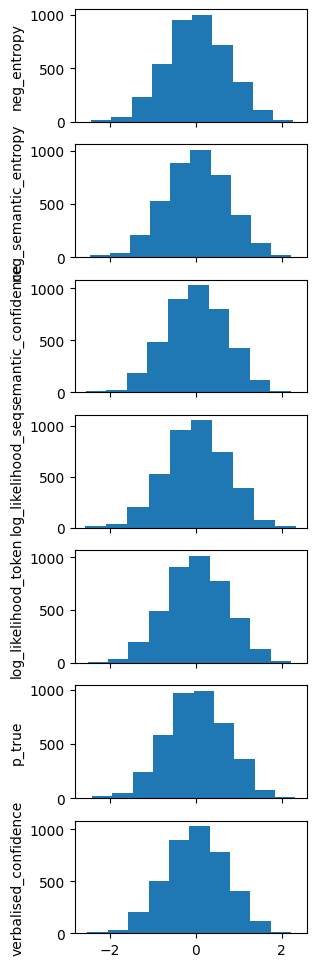

In [34]:
fig, axs = plt.subplots(len(ds.sys2id), 1, sharex=True, figsize=(3,12))

for s, system in enumerate(ds.sys2id.objects):
    axs[s].hist(posterior_samples['bs'][:,s])
    axs[s].set_ylabel(system)

In [322]:
# fig, axs = plt.subplots(len(ds.judge2id), 1, sharex=True, figsize=(3,12))

# for j, judge in enumerate(ds.judge2id.objects):
#     axs[j].hist(posterior_samples['bj'][:,j])
#     axs[j].set_ylabel(judge)

In [323]:
# fig, axs = plt.subplots(len(ds.sys2id), len(ds.judge2id), sharex=True, figsize=(16,16))
# for j, judge in enumerate(ds.judge2id.objects):
#     for s, system in enumerate(ds.sys2id.objects):
#         axs[s, j].hist(posterior_samples['w'][:,j, s])
#         axs[s, 0].set_ylabel(system)
#         axs[0, j].set_title(judge)

The slopes will capture a predictive association between the confidence score and the judge. A positive slope means that the confidence score is a useful predictor of the judgments.

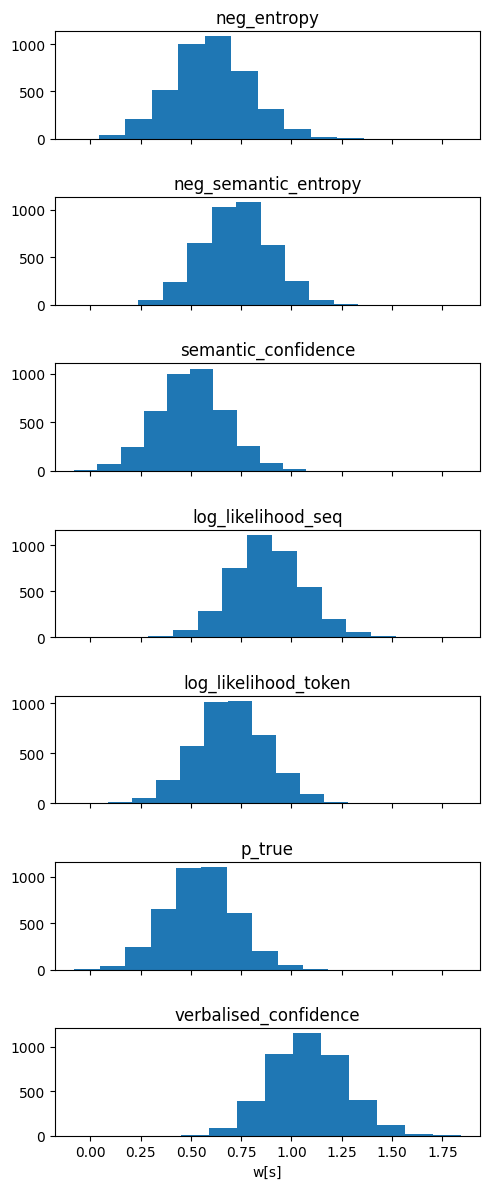

In [36]:
fig, axs = plt.subplots(len(ds.sys2id), 1, sharex=True, figsize=(5,12))
for s, system in enumerate(ds.sys2id.objects):
    axs[s].hist(posterior_samples['w'][:,s])
    axs[s].set_title(system)
    axs[-1].set_xlabel("w[s]")

fig.tight_layout(h_pad=2, w_pad=2)

In [37]:
# # fig, axs = plt.subplots(len(ds.sys2id), len(ds.judge2id), sharex=True, figsize=(12,12))
# for j, judge in enumerate(ds.judge2id.objects):
#     for s, system in enumerate(ds.sys2id.objects):
#         print(judge, system, (posterior_samples['w'][:,j, s] > 0.).mean())        

# Detailed Analysis

Now we use posterior confidence (that is, $\operatorname{sigmoid}(z_i)$) as a quantity that can be compared across systems and judges. 

We analyse judges in terms of how their predictions compared to a trusted judge (an oracle). When the judge is right (correct) its predictions are TN or TP. When the judge is wrong (incorrect) its predictions are FN or FP. When the judge is right, we collect good data for evaluation of the uncertainty quantifier that mediate our decisions (via selective generation, AUROC, etc), but when the judge is wrong we distort the evaluation results. Unfortunately, the ways in which a judge can be wrong can correlate with the ways in which confidence distributes leading to unjustified penalties and rewards that do not cancel each other. Here we seek to analyse precisely that.

We plot confidence against (TN, TP) and (FN, FP). We colour-code interesting regions of the plot, in particular, regions corresponding to incorrect judgements (FN and FP). When confidence is high a selective generator will commit to a response, when confidence is low a selective generator will refrain from responding. If we pair these two situations with FN and FP, we identify: unfair penalties (FP and low confidence; FN and high confidence) and unfair rewards (FP and high confidence; FN and low confidence). These are shown as red and green regions, respectively, in the plot.

In [39]:
import pandas as pd

In [40]:
df = pd.DataFrame({
    "item": ds.I,
    "system": ds.S,
    "score": np.median(posterior_samples['theta'], 0),
    "judge": ds.A,
    "label": ds.Y,
})

**Remark** I am not very good at writing pandas code, and I used gemini's suggestions for this bit. Better/cleaner code might be a good idea.

In [44]:
oracle_judge = ds.judge2id('human_judge1')
oracle_judge

0

In [45]:
oracle_df = (
    df[df["judge"] == oracle_judge]
    .loc[:, ["item", "system", "label"]]
    .rename(columns={"label": "oracle_label"})
)
non_oracle_df = df[df["judge"] != oracle_judge]
joined = non_oracle_df.merge(oracle_df, on=["item", "system"], how="inner")
joined["agree"] = (joined["label"] == joined["oracle_label"]).astype(int)
systems = joined["system"].unique()

In [46]:
ds.sys2id.objects

['neg_entropy',
 'neg_semantic_entropy',
 'semantic_confidence',
 'log_likelihood_seq',
 'log_likelihood_token',
 'p_true',
 'verbalised_confidence']

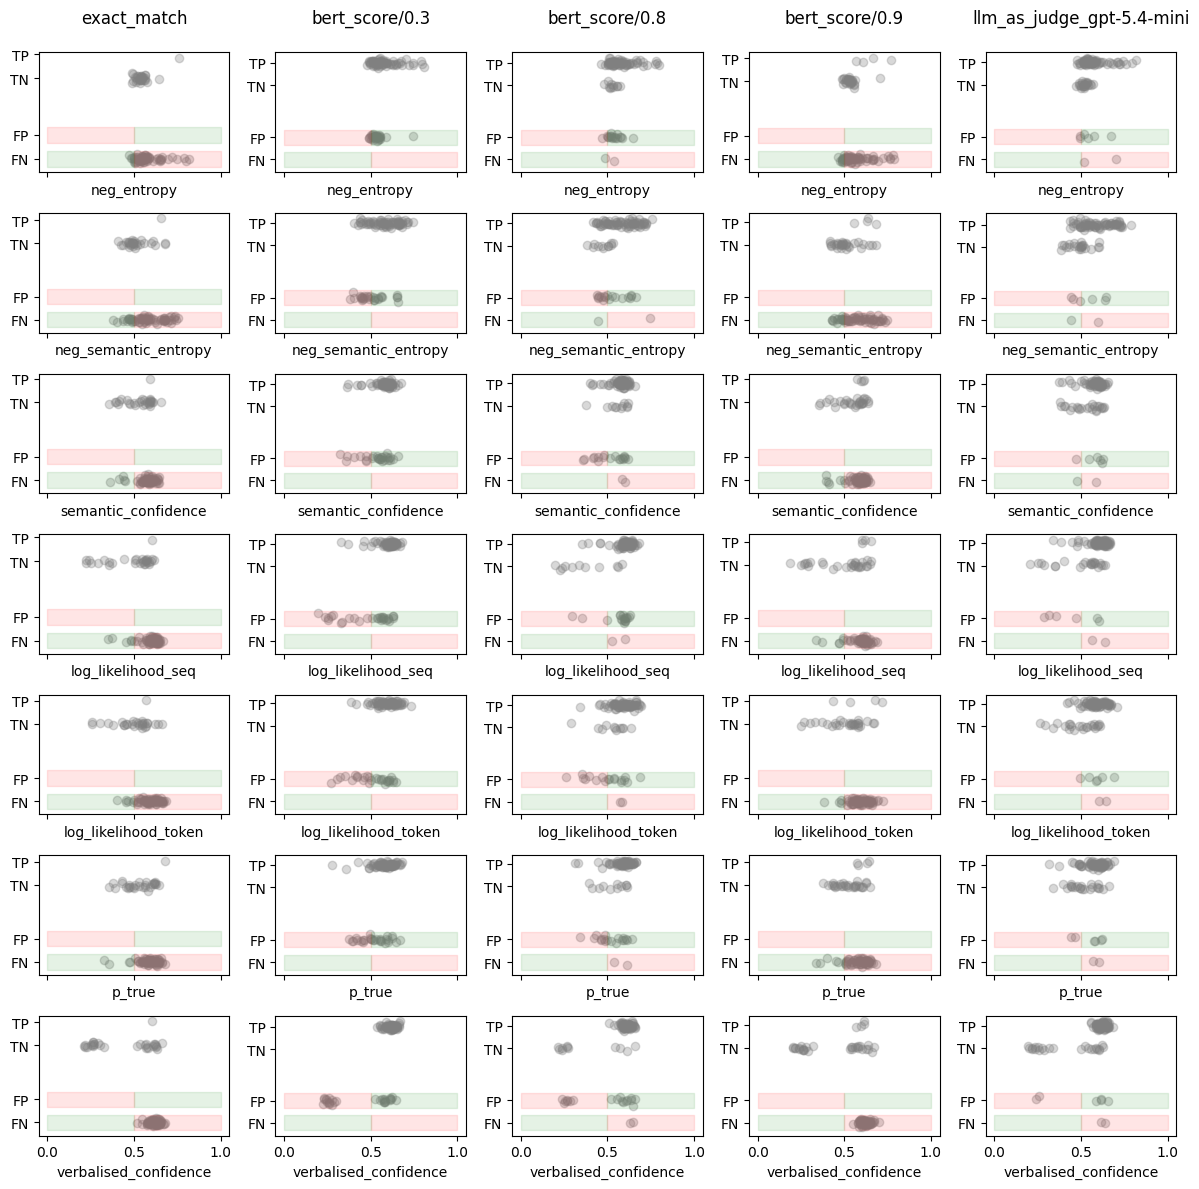

In [47]:
# num_judges - 1 because we don't plot the oracle
fig, axs = plt.subplots(len(ds.sys2id), len(ds.judge2id)-1, sharex=True, figsize=(12,12))

for sys_id, sys_name in enumerate(ds.sys2id.objects):
    
    sub = joined[joined["system"] == sys_id]
    
    for j_id, j_name in enumerate(ds.judge2id.objects):
        col = j_id
        if j_id == oracle_judge:
            continue
        if j_id > oracle_judge: # adjust col number to leave the oracle out
            col = j_id - 1
                    
        sj = sub[sub["judge"] == j_id]
        axs[sys_id, col].scatter(
            sj["score"] + np.random.normal(0., 0.025, size=sj["score"].size), # some normal jitter
            sj["agree"]+0.3*sj["label"]+np.random.normal(0., 0.025, size=sj["score"].size), # I shift the TP up by +0.3; and add some normal jitter
            alpha=0.3,
            color='gray',
            label=f"judge {ds.judge2id[j_id]}",
        )
        
        axs[sys_id, col].set_xlabel(sys_name) #
        axs[0, col].set_title(f"{j_name}\n")
        axs[sys_id, col].set_yticks([0, 0.3, 1, 1.3], ["FN", "FP", "TN", "TP"])
        
        axs[sys_id, col].fill_between(np.linspace(0., 0.5), -0.1, 0.1, color='green', alpha=0.1)
        axs[sys_id, col].fill_between(np.linspace(0.5, 1.), -0.1, 0.1, color='red', alpha=0.1)
        axs[sys_id, col].fill_between(np.linspace(0., 0.5), 0.2, 0.4, color='red', alpha=0.1)
        axs[sys_id, col].fill_between(np.linspace(0.5, 1.), 0.2, 0.4, color='green', alpha=0.1)


fig.tight_layout(h_pad=1, w_pad=1)